In [262]:
import pennylane as qp
from pennylane import FermiC, FermiA
from pennylane import numpy as plnp

import numpy as np
import matplotlib.pyplot as plt

In [263]:
t = 1.0
U = 4.0

n_sites = 2
n_elec = (1, 1)
n_spin_orbitals = 2 * sum(n_elec)

In [264]:
# Use site site grouping
H_fermi = (-t * ((FermiC(0) * FermiA(2)) + (FermiC(2) * FermiA(0)) + (FermiC(1) * FermiA(3)) + (FermiC(3) * FermiA(1)))
           +  U * ((FermiC(0) * FermiA(0) * FermiC(1) * FermiA(1)) + (FermiC(2) * FermiA(2) * FermiC(3) * FermiA(3))))

H_qubit = qp.jordan_wigner(H_fermi)

n_qubits = len(H_qubit.wires)

In [265]:
coeffs, observables = H_qubit.terms()

coeffs_real = qp.math.real(coeffs)

H_qubit = qp.dot(coeffs_real, observables)

In [266]:
eigvals, eigvecs = np.linalg.eigh(H_qubit.sparse_matrix().toarray())
(eigvals)

array([-1.00000000e+00, -1.00000000e+00, -8.28427125e-01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  2.84648128e-66,  1.00000000e+00,
        1.00000000e+00,  3.00000000e+00,  3.00000000e+00,  4.00000000e+00,
        4.82842712e+00,  5.00000000e+00,  5.00000000e+00,  8.00000000e+00])

In [267]:
HF_state = qp.qchem.hf_state(sum(n_elec), n_qubits)

singles, doubles = qp.qchem.excitations(sum(n_elec), n_qubits)

s_wires, d_wires = qp.qchem.excitations_to_wires(singles, doubles)

dev = qp.device("default.qubit", wires=n_qubits)

@qp.qnode(dev)
def cost_function(theta):
    qp.UCCSD(weights=theta, s_wires=s_wires, d_wires=d_wires, wires=range(n_qubits), init_state=HF_state)
    
    return qp.expval(H_qubit)

optimiser = qp.GradientDescentOptimizer(0.01)

n_params = len(singles) + len(doubles)
params = plnp.zeros(n_params, requires_grad=True)

diff = 1
prev_energy = 0
tol = 1e-8
counter = 0
energy_history = []

while abs(diff) > tol:
    params, energy = optimiser.step_and_cost(cost_function, params)
    diff = energy - prev_energy
    prev_energy = energy

    counter += 1
    energy_history.append(energy)

The ground state energy is -0.8284269578630584 Ha.


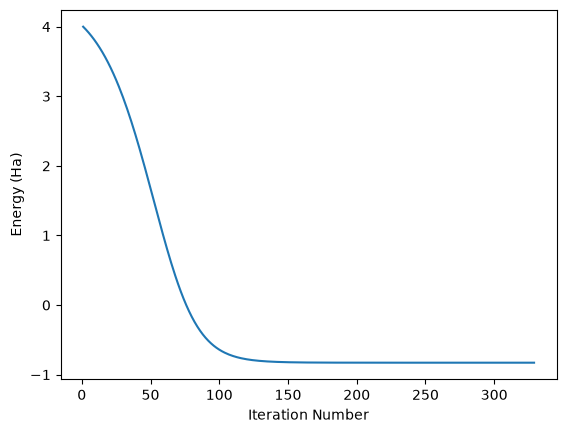

In [270]:
plt.plot(range(1, counter + 1), energy_history)

plt.xlabel('Iteration Number')
plt.ylabel('Energy (Ha)')

print(f'The ground state energy is {min(energy_history)} Ha.')

plt.show()